In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import HumanMessage,BaseMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver


In [2]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):

    messages:Annotated[list[BaseMessage],add_messages]


In [3]:
llm=ChatGroq(model="llama-3.3-70b-versatile")
def chat_node(state:ChatState):
    #take user query form state
    messages=state['messages']

    #send to llm
    response=llm.invoke(messages)

    # response store state
    return {"messages":[response]}

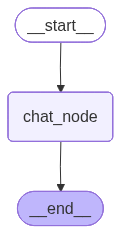

In [13]:
checkpointer=MemorySaver()

graph=StateGraph(ChatState)
graph.add_node("chat_node",chat_node)

graph.add_edge(START,"chat_node")
graph.add_edge("chat_node",END)

chatbot=graph.compile(checkpointer=checkpointer)
chatbot

In [ ]:
initial_state={
    "messages":[HumanMessage(content="what is the capital of India")]
}

chatbot.invoke(initial_state)['messages'][-1].content

{'messages': [HumanMessage(content='what is the capital of India', additional_kwargs={}, response_metadata={}, id='4cf82e8d-dd3e-4307-8673-4bc5d4cf33c7'),
  AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 41, 'total_tokens': 52, 'completion_time': 0.025131717, 'completion_tokens_details': None, 'prompt_time': 0.001965314, 'prompt_tokens_details': None, 'queue_time': 0.286847017, 'total_time': 0.027097031}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4ed4-0205-7551-91aa-81364b687363-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 11, 'total_tokens': 52})]}

In [14]:
thread_id='1'
while True:

    user_input=input("Type Here:")
    print("user:",user_input)

    if user_input.strip().lower() in ["quit","bye","end"]:
        break

    config={'configurable':{'thread_id':thread_id}}
    response=chatbot.invoke({"messages":[HumanMessage(content=user_input)]},config=config)
    print("AI message",response["messages"][-1].content)

user: hai
AI message Hai, how can I help you today?
user: who is known as king of cricket
AI message The player widely known as the "King of Cricket" is Sir Garfield Sobers, but in modern times, the title is often associated with Sir Vivian Richards or Sachin Tendulkar. However, Sachin Tendulkar is more commonly referred to as the "God of Cricket".

That being said, Sir Garfield Sobers is often considered the greatest all-rounder in cricket history, and his impressive career statistics and achievements have earned him the nickname "King of Cricket".

But if I had to pick one player who is most commonly referred to as the "King of Cricket", I would say it's Sir Vivian Richards. He was a dominant force in West Indian cricket during the 1970s and 1980s, known for his aggressive batting style and leadership on the field.

So, while there are a few players who could be considered the "King of Cricket", Sir Vivian Richards is probably the most widely recognized with this nickname.
user: who 

In [15]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hai', additional_kwargs={}, response_metadata={}, id='ab76bf1d-ff4c-4a25-82bd-dca24a283cdf'), AIMessage(content='Hai, how can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 36, 'total_tokens': 47, 'completion_time': 0.039653748, 'completion_tokens_details': None, 'prompt_time': 0.002149642, 'prompt_tokens_details': None, 'queue_time': 0.161168337, 'total_time': 0.04180339}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4eeb-57f2-7503-b84d-37155c3668db-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 11, 'total_tokens': 47}), HumanMessage(content='who is known as king of cricket', additional_kwargs={}, response_metadata={}, id='de4a84e1-2d42-4bb5-a9ed-66a64449b4fe'), A